# Conditional Workflows

### Quadratic Equation Workflow(non LLM)

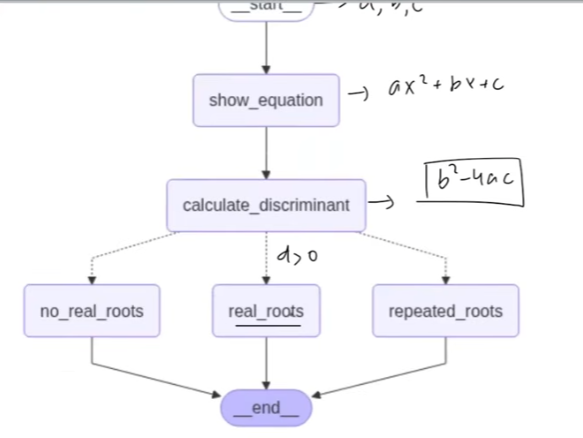

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):
    a : int
    b : int 
    c : int
    equation : str
    disc : float
    result : str

In [12]:
def Show_equation(state : QuadState):
    equation = f"{state['a']}x2 + {state['b']}x + {state['c']}"
    return {'equation' : equation}

def calculate_disc(state : QuadState):
    disc = state['b']**2 - 4 * (state['a'] * state['c'])
    return {'disc' : disc}

def real_roots(state : QuadState):
    root1 = (-state['b'] + state['disc']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['disc']**0.5) / (2*state['a'])

    result = f"The roots are {root1} and {root2}"
    return {'result' : result}

def repeated_root(state : QuadState):
    root = (-state['b']) / (2*state['a'])

    result = f"The root is {root}"
    return {'result' : result}

def no_real_roots(state : QuadState):

    result = f"The equation has no real roots"
    return {'result' : result}


def check_condition(state : QuadState) -> Literal['real_roots', 'repeated_root', 'no_real_roots']:
    
    if state['disc'] > 0:
        return 'real_roots'
    elif state['disc'] == 0:
        return 'repeated_root'
    else:
        return 'no_real_roots'
    

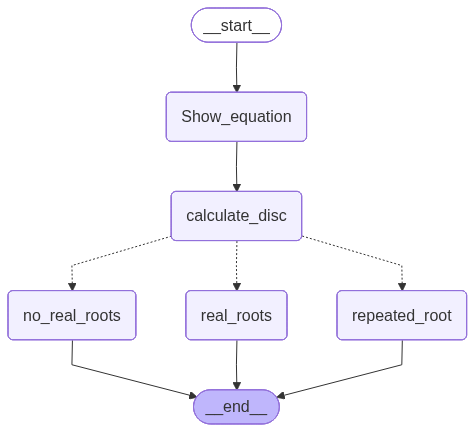

In [14]:
graph = StateGraph(QuadState)

graph.add_node('Show_equation', Show_equation)
graph.add_node('calculate_disc', calculate_disc)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_root', repeated_root)
graph.add_node('no_real_roots', no_real_roots)


graph.add_edge(START, 'Show_equation')
graph.add_edge('Show_equation', 'calculate_disc')
graph.add_conditional_edges('calculate_disc', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_root', END)
graph.add_edge('no_real_roots', END)

graph.compile()


In [15]:
workflow = graph.compile()

In [16]:
initial_state = {
    'a' : 4,
    'b' : 2,
    'c' : 4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4x2 + 2x + 4',
 'disc': -60,
 'result': 'The equation has no real roots'}

In [17]:
## The above was the flow without LLM the below will be using LLM using conditional workflow

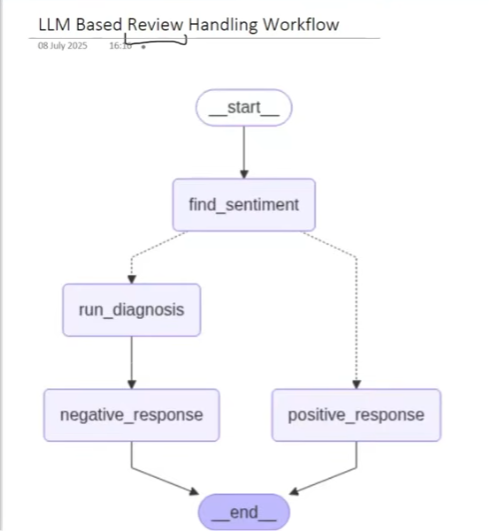

In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

load_dotenv()

model = ChatOllama(
    model="llama3",  # or any model you have pulled
    temperature=0
)

c:\Users\HP\Documents\Coding journeys\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
class SentimentSchema(BaseModel):
    sentiment : Literal['positive', 'negative'] = Field(description='Sentiment of the review')

class DiagnosisSchema(BaseModel):
    issue_type : Literal['UX', 'Performance', 'Bug', "Support", 'Other'] = Field(description='The category of issur mentioned in the review')
    tone : Literal['angry', 'frustrated', 'disappointed', 'calm'] = Field(description='The emotional tome expressed by the user')
    urgency : Literal['low', 'medium', 'high'] = Field(description='How urgent or critical the issure appears to be')

In [39]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [ ]:
prompt = "Good,  product"
structured_model.invoke(prompt)


SentimentSchema(sentiment='positive')

In [36]:
class ReviewState(TypedDict):
    review : str
    sentiment : str
    diagnosis : dict
    response : str

In [41]:
def find_sentiment(state : ReviewState):
    prompt = f'For the following review find out the sentiment \n {state['review']}'

    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment' : sentiment}

def check_sentiment(state : ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    

def positive_response(state : ReviewState):
    prompt = f"""
    Write a warm thank you message in the response to this review
    \n {state['review']}
    Also Kindly ask the user to leave feedback on our website
    """
    
    response = model.invoke(prompt).content
    return {'response' : response}

def run_diagnosis(state : ReviewState):
    prompt : """
    f"Diagnosis this negative review : \n\n{state['review]}\n"
    "return issue_type, tone and urgency.
    """
    
    response = structured_model2.invoke(prompt)
    return {'diagnosis' : response.model_dump()}

def negative_response(state : ReviewState):
    diagnosis = state['diagnosis']
    prompt = """
    You are a support assistant.RecursionErrorThe user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}' and marked urgency as {diagnosis['urgency']}
    Write an empathetic, helpful resultution message
    """

    response = model.invoke(prompt).content
    return {'response' : response}


In [42]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()


In [44]:
initial_state = {
    'review' : 'The product is fucking amazing'
}

workflow.invoke(initial_state)

{'review': 'The product is fucking amazing',
 'sentiment': 'positive',
 'response': 'Dear [User],\n\nWe are absolutely thrilled to hear that you think our product is "fucking amazing"! We\'re so glad that it has exceeded your expectations and provided a positive experience for you.\n\nAs we continue to strive for excellence, your feedback is invaluable in helping us improve and create even better products for our customers. Would you kindly take a moment to leave a review on our website? Your thoughts will help others make informed purchasing decisions and allow us to refine our offerings.\n\nOnce again, thank you for your kind words and for choosing our product. We\'re honored to have had the opportunity to serve you!\n\nBest regards,\n[Your Name/Company]'}

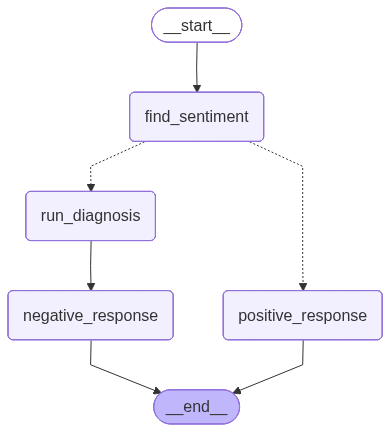

In [43]:
workflow